In [1]:
"""
NLDAS Noah Actual Evapotranspiration (ET) Download for Iowa (2015-2024)

This notebook downloads NLDAS-2 Noah Land Surface Model monthly actual
evapotranspiration data for Iowa using NASA's earthaccess library.

Study period extended from 2019-2023 to 2015-2024 to support a 10-year analysis
aligned with SIF (OCO-2 from 2014-09), Drought Monitor (from 2015-01), and CDL data.

PURPOSE:
--------
Download actual ET from the Noah LSM to compare with OpenET (actual ET including
irrigation) for irrigation detection:
    HumanET = OpenET - NLDAS_Noah_ET

Where OpenET > NLDAS Noah ET, the excess water inputs beyond what the land surface
model predicts indicate irrigation or other human water additions.

Dataset: NLDAS Noah Land Surface Model L4 Monthly 0.125 x 0.125 degree V2.0
Short Name: NLDAS_NOAH0125_M
DOI: 10.5067/WB224IA3PVOJ
Variable: Evap (Total Evapotranspiration)
Units: kg/m2 (monthly accumulated, equivalent to mm)

Expected output: 120 files (12 months x 10 years: 2015-2024)
  NLDAS_NOAH0125_M.AYYYYMM.020.nc → data/raw/NLDAS_Noah/

Requirements:
- earthaccess library
- NASA Earthdata account (~/.netrc)
"""

"\nNLDAS Noah Actual Evapotranspiration (ET) Download for Iowa (2015-2024)\n\nThis notebook downloads NLDAS-2 Noah Land Surface Model monthly actual\nevapotranspiration data for Iowa using NASA's earthaccess library.\n\nStudy period extended from 2019-2023 to 2015-2024 to support a 10-year analysis\naligned with SIF (OCO-2 from 2014-09), Drought Monitor (from 2015-01), and CDL data.\n\nPURPOSE:\n--------\nDownload actual ET from the Noah LSM to compare with OpenET (actual ET including\nirrigation) for irrigation detection:\n    HumanET = OpenET - NLDAS_Noah_ET\n\nWhere OpenET > NLDAS Noah ET, the excess water inputs beyond what the land surface\nmodel predicts indicate irrigation or other human water additions.\n\nDataset: NLDAS Noah Land Surface Model L4 Monthly 0.125 x 0.125 degree V2.0\nShort Name: NLDAS_NOAH0125_M\nDOI: 10.5067/WB224IA3PVOJ\nVariable: Evap (Total Evapotranspiration)\nUnits: kg/m2 (monthly accumulated, equivalent to mm)\n\nExpected output: 120 files (12 months x 10 

In [2]:
import sys
import subprocess

# Install to your home directory
target_dir = '/home/jcoldiron/.local/lib/python3.12/site-packages'
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', 
    '--target=' + target_dir,
    'earthaccess'
])

# Add to Python path
if target_dir not in sys.path:
    sys.path.insert(0, target_dir)

print(f"Installed to: {target_dir}")
print("Now try: import earthaccess")

# Install earthaccess if needed
# pip install earthaccess

import earthaccess
print(f"earthaccess version: {earthaccess.__version__}")

  Using cached multimethod-2.0.2-py3-none-any.whl.metadata (8.4 kB)
  Using cached pqdm-0.2.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached python_cmr-0.13.0-py3-none-any.whl.metadata (10 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached tinynetrc-1.3.1-py2.py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached bounded_pool_executor-0.0.3-py3-none-any.whl.metadata (2.7 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached charset_normalizer-3.4.7-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-an


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


Installed to: /home/jcoldiron/.local/lib/python3.12/site-packages
Now try: import earthaccess
earthaccess version: 0.17.0


/home/jcoldiron/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path

# Authenticate with NASA Earthdata (uses ~/.netrc credentials)
auth = earthaccess.login()

# =============================================================================
# Configuration for Iowa 2015-2024 (10-year study period)
# =============================================================================

# Full 10-year temporal range: aligned to Drought Monitor start (2015-01)
# and NLDAS data availability. NLDAS-2 Noah goes back to 1979, so 2015 is fine.
start_year = 2015
end_year   = 2024
temporal_range = (f"{start_year}-01-01", f"{end_year}-12-31")

# Iowa bounding box (west, south, east, north)
iowa_bbox = (-96.64, 40.38, -90.14, 43.50)

# Project paths - relative to notebook location
project_root = Path("../../..").resolve()
local_path = project_root / "data" / "raw" / "NLDAS_Noah"
local_path.mkdir(parents=True, exist_ok=True)

n_expected = (end_year - start_year + 1) * 12

print(f"Project root:     {project_root}")
print(f"Download path:    {local_path}")
print(f"Temporal range:   {temporal_range}")
print(f"Expected granules: {n_expected} (12 months x {end_year - start_year + 1} years)")
print(f"Bounding box (Iowa): {iowa_bbox}")

# Count already-downloaded files to determine how many remain
existing = list(local_path.glob("NLDAS_NOAH0125_M.A*.nc"))
print(f"\nFiles already on disk: {len(existing)}")
print(f"Files still needed:    {max(0, n_expected - len(existing))}")

# =============================================================================
# Search and Download NLDAS Noah LSM Monthly Data
# =============================================================================

print(f"\nSearching NLDAS Noah LSM monthly data for {start_year}-{end_year}...")

results = earthaccess.search_data(
    doi="10.5067/WB224IA3PVOJ",  # NLDAS Noah Land Surface Model L4 Monthly
    temporal=temporal_range,
    bounding_box=iowa_bbox
)

print(f"Found {len(results)} granules")

if results:
    downloaded_files = earthaccess.download(results, local_path=str(local_path))
    print(f"\nDownloaded {len(downloaded_files)} files to: {local_path}")
else:
    print("No data found for the specified parameters")

print("\nDownload complete!")

Project root:     /home/pielab-sandbox-jcoldiron/SIF-Analysis
Download path:    /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/raw/NLDAS_Noah
Temporal range:   ('2015-01-01', '2024-12-31')
Expected granules: 120 (12 months x 10 years)
Bounding box (Iowa): (-96.64, 40.38, -90.14, 43.5)

Files already on disk: 60
Files still needed:    60

Searching NLDAS Noah LSM monthly data for 2015-2024...
Found 120 granules


QUEUEING TASKS | : 100%|██████████| 120/120 [00:00<00:00, 13521.29it/s]
PROCESSING TASKS | : 100%|██████████| 120/120 [00:10<00:00, 11.54it/s]
COLLECTING RESULTS | : 100%|██████████| 120/120 [00:00<00:00, 645277.54it/s]


Downloaded 120 files to: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/raw/NLDAS_Noah

Download complete!


In [6]:
"""
Process and Clip NLDAS Noah Actual ET Data to Iowa Boundary

This cell:
1. Loads each downloaded Noah LSM NetCDF file
2. Extracts the total evapotranspiration (Evap) variable
3. Clips to Iowa state boundary
4. Saves clipped files and computes annual summaries

Evap units: kg/m2 (monthly accumulated total, equivalent to mm/month)
No rate conversion needed.
"""

import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import pandas as pd
from pathlib import Path

# =============================================================================
# File Paths
# =============================================================================

project_root = Path("../../..").resolve()

input_folder = project_root / "data" / "raw" / "NLDAS_Noah"
output_folder = project_root / "data" / "processed" / "NLDAS_Noah_Iowa"
output_folder.mkdir(parents=True, exist_ok=True)

iowa_boundary = project_root / "data" / "aoi" / "iowa.geojson"

print(f"Input folder: {input_folder}")
print(f"Output folder: {output_folder}")

nc_files = sorted(input_folder.glob("*.nc"))
print(f"Found {len(nc_files)} NetCDF files to process")

# Inspect variables in first file
if nc_files:
    ds_sample = xr.open_dataset(nc_files[0])
    print(f"\nVariables in dataset: {list(ds_sample.data_vars)}")
    if "Evap" in ds_sample:
        print(f"Evap attributes: {ds_sample['Evap'].attrs}")
    ds_sample.close()

# =============================================================================
# Load Iowa Boundary
# =============================================================================

gdf = gpd.read_file(iowa_boundary)
print(f"\nIowa boundary CRS: {gdf.crs}")

# =============================================================================
# Process Each NetCDF File - Extract Evap
# =============================================================================

all_clipped = []

for file in nc_files:
    try:
        ds = xr.open_dataset(file)
        data = ds["Evap"]
        
        # Set CRS
        data = data.rio.write_crs("EPSG:4326")
        
        # Clip to Iowa
        gdf_projected = gdf.to_crs(data.rio.crs)
        clipped = data.rio.clip(gdf_projected.geometry, gdf_projected.crs, drop=True)
        
        all_clipped.append(clipped)
        
        # Save clipped file
        filename = file.stem + "_Evap_Iowa.nc"
        output_path = output_folder / filename
        clipped.to_netcdf(output_path)
        
        print(f"Processed: {file.name} -> {filename}")
        
    except Exception as e:
        print(f"Error processing {file.name}: {e}")

print(f"\nProcessed {len(all_clipped)} files total")

# =============================================================================
# Compute Annual Summaries (2019-2023)
# =============================================================================

if all_clipped:
    combined = xr.concat(all_clipped, dim="time")
    
    # Overall mean monthly ET across all 60 months
    mean_et = combined.mean(dim="time", keep_attrs=True)
    if 'lat' in mean_et.dims and mean_et.lat[0] < mean_et.lat[-1]:
        mean_et = mean_et.sortby('lat', ascending=False)
    
    mean_output = output_folder / "ET_mean_monthly_2019_2023_Iowa.tif"
    mean_et.rio.to_raster(mean_output)
    print(f"\nSaved 5-year mean monthly ET: {mean_output}")
    
    print(f"\nMean monthly ET: {float(mean_et.mean()):.1f} mm/month")
    print(f"Note: Evap values are monthly totals in kg/m2 (= mm)")

print("\nProcessing complete!")

Input folder: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/raw/NLDAS_Noah
Output folder: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/NLDAS_Noah_Iowa
Found 120 NetCDF files to process

Variables in dataset: ['time_bnds', 'SWdown', 'LWdown', 'SWnet', 'LWnet', 'Qle', 'Qh', 'Qg', 'Qf', 'Snowf', 'Rainf', 'Evap', 'Qs', 'Qsb', 'Qsm', 'AvgSurfT', 'Albedo', 'SWE', 'SnowDepth', 'SnowFrac', 'SoilT_0_10cm', 'SoilT_10_40cm', 'SoilT_40_100cm', 'SoilT_100_200cm', 'SoilM_0_10cm', 'SoilM_10_40cm', 'SoilM_40_100cm', 'SoilM_100_200cm', 'SoilM_0_100cm', 'SoilM_0_200cm', 'RootMoist', 'SMLiq_0_10cm', 'SMLiq_10_40cm', 'SMLiq_40_100cm', 'SMLiq_100_200cm', 'SMAvail_0_100cm', 'SMAvail_0_200cm', 'PotEvap', 'ECanop', 'TVeg', 'ESoil', 'SubSnow', 'CanopInt', 'ACond', 'CCond', 'RCS', 'RCT', 'RCQ', 'RCSOL', 'RSmin', 'RSMacr', 'LAI', 'GVEG', 'Streamflow']
Evap attributes: {'units': 'kg m-2', 'standard_name': 'Total evapotranspiration', 'long_name': 'Total evapotranspiration', 'cell_methods': 'time: 

Mean monthly ET statistics (mm/month):
  Min: 32.0
  Max: 56.4
  Mean: 48.0


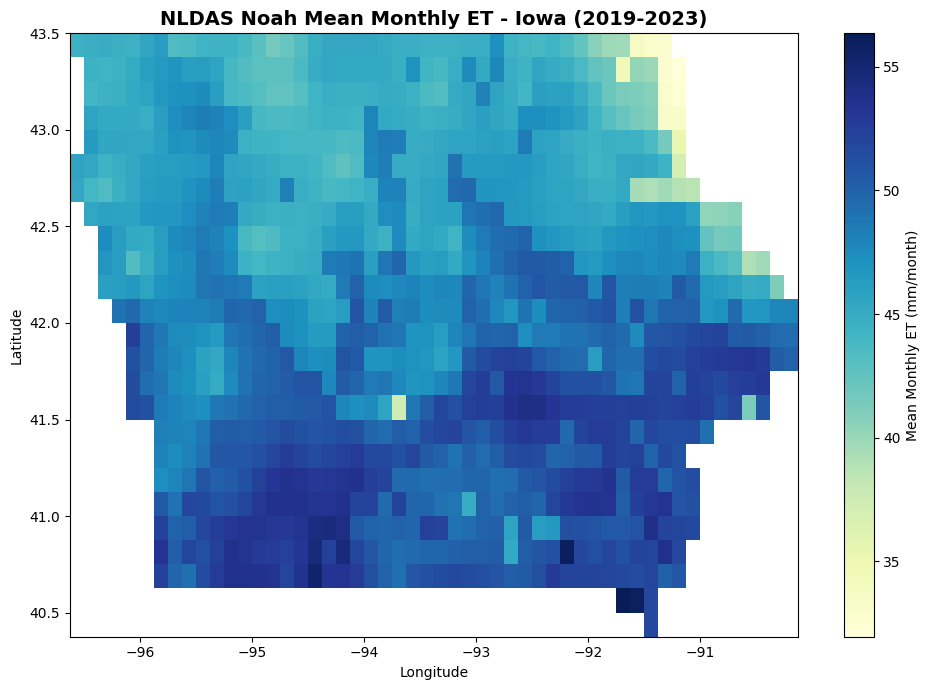


Note: These are actual ET values from the Noah Land Surface Model.
Compare with NLDAS forcing PET to compute irrigation signal:
  PET - ET = Irrigation signal


In [7]:
"""
Visualize Noah Actual Evapotranspiration for Iowa (2019-2023)
"""

import matplotlib.pyplot as plt
import numpy as np

# Quick sanity check on the mean ET values
print(f"Mean monthly ET statistics (mm/month):")
print(f"  Min: {float(mean_et.min()):.1f}")
print(f"  Max: {float(mean_et.max()):.1f}")
print(f"  Mean: {float(mean_et.mean()):.1f}")

# Plot mean monthly ET
fig, ax = plt.subplots(figsize=(10, 7))

mean_et.plot(
    ax=ax,
    cmap='YlGnBu',
    cbar_kwargs={'label': 'Mean Monthly ET (mm/month)'}
)

ax.set_title('NLDAS Noah Mean Monthly ET - Iowa (2019-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print(f"\nNote: These are actual ET values from the Noah Land Surface Model.")
print(f"Compare with NLDAS forcing PET to compute irrigation signal:")
print(f"  PET - ET = Irrigation signal")